Визуальная одометрия: реализация с нуля

В этом руководстве представлена полная реализация системы визуальной одометрии на основе последовательности фотографий. Код написан на Python и предназначен для выполнения в Jupyter Notebook (например, в VS Code). Все ключевые алгоритмы (фильтры, детектор блобов, дескриптор SIFT, сопоставление, оценка движения) реализованы вручную без использования готовых функций компьютерного зрения, за исключением ввода/вывода изображений и визуализации.

1. Подготовка данных

Сделайте не менее 8 фотографий, перемещая камеру по квадрату: вправо → вперёд → влево → назад → в исходную точку. Сохраните их в папке images/ с именами, например, frame_01.jpg, frame_02.jpg, ….

2. Импорт библиотек и вспомогательные функции

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, minimum_filter
from scipy.spatial.distance import cdist
import cv2  # только для загрузки/сохранения и визуализации
import os
from typing import List, Tuple, Optional

In [2]:
import os
print("Текущая папка:", os.getcwd())
print("Содержимое текущей папки:", os.listdir('.'))

Текущая папка: d:\Libraries\Documents\VScode\CV_labs_Plotnikov_8E21\Lab_2
Содержимое текущей папки: ['2.0_CV_lab_2_Plotnikov_8E21.ipynb', '3.0_CV_lab_2_Plotnikov_8E21.ipynb', 'bad_output_1', 'CV_lab_2_Plotnikov_8E21.ipynb', 'output', 'Pictures1', 'Pictures2', 'Pictures3', 'Pictures4']


In [ ]:
# def pad_reflect(arr: np.ndarray, pad_width: int) -> np.ndarray:
#     """Зеркальное отражение границ."""
#     if pad_width == 0:
#         return arr
#     return np.pad(arr, pad_width, mode='reflect')

# def convolve2d_manual(img: np.ndarray, kernel: np.ndarray) -> np.ndarray:
#     """
#     Ручная двумерная свёртка с зеркальным отражением границ.
#     """
#     kh, kw = kernel.shape
#     pad_h, pad_w = kh // 2, kw // 2
#     padded = pad_reflect(img, ((pad_h, pad_h), (pad_w, pad_w)))
#     out = np.zeros_like(img, dtype=np.float64)
    
#     for i in range(img.shape[0]):
#         for j in range(img.shape[1]):
#             region = padded[i:i+kh, j:j+kw]
#             out[i, j] = np.sum(region * kernel)
#     return out

In [13]:
from numpy.lib.stride_tricks import sliding_window_view

def convolve2d_manual(img: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Векторизованная свёртка с отражением границ (быстрая).
    """
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    windows = sliding_window_view(padded, (kh, kw))
    # windows shape: (H, W, kh, kw)
    out = np.einsum('ijkl,kl->ij', windows, kernel)
    return out

3. Загрузка и перевод в градации серого (ручная реализация)

In [ ]:
def rgb_to_grayscale(img: np.ndarray) -> np.ndarray:
    """
    Ручной перевод BGR/RGB в оттенки серого.
    Используется стандартная формула: Y = 0.299*R + 0.587*G + 0.114*B
    """
    if img.ndim == 2:
        return img
    # предполагаем порядок каналов BGR (OpenCV)
    b, g, r = img[:,:,0], img[:,:,1], img[:,:,2]
    gray = 0.114 * b + 0.587 * g + 0.299 * r
    return gray.astype(np.float32)

def load_images(folder: str, verbose=False) -> List[np.ndarray]:
    """
    Загружает все .jpg из указанной папки, сортируя по числовому значению имени файла.
    Поддерживает имена вида '1.jpg', '2.jpg', ..., '10.jpg'.
    """
    import re
    files = [f for f in os.listdir(folder) if f.lower().endswith('.jpg')]
    # Извлекаем числовой номер из имени файла для корректной сортировки
    def extract_number(filename):
        match = re.search(r'(\d+)', filename)
        return int(match.group(1)) if match else 0
    files.sort(key=extract_number)
    
    images = []
    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        if img is None:
            print(f"Предупреждение: не удалось загрузить {f}")
            continue
        gray = rgb_to_grayscale(img)
        
        # Сжатие в 4 раза
        new_h, new_w = gray.shape[0] // 4, gray.shape[1] // 4
        gray = cv2.resize(gray, (new_w, new_h), interpolation=cv2.INTER_AREA)
        
        images.append(gray)
        print(f"Загружено: {f}")
    print(f"Всего загружено {len(images)} изображений.")
    return images

4. Фильтры (ручная реализация)

In [ ]:
def gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """Генерация одномерного ядра Гаусса."""
    ax = np.arange(-size//2 + 1., size//2 + 1.)
    kernel = np.exp(-0.5 * (ax / sigma) ** 2)
    return kernel / kernel.sum()

def gaussian_blur(img: np.ndarray, sigma: float) -> np.ndarray:
    """Свёртка с Гауссом через разделимые фильтры."""
    ksize = int(2 * np.ceil(3 * sigma) + 1)
    kernel = gaussian_kernel(ksize, sigma).reshape(1, -1)
    # горизонтальная свёртка
    blur = convolve2d_manual(img, kernel, mode='reflect')
    # вертикальная свёртка
    blur = convolve2d_manual(blur, kernel.T, mode='reflect')
    return blur

def image_pyramid(img: np.ndarray, n_octaves: int = 4, n_scales: int = 5, sigma0: float = 1.6) -> List[List[np.ndarray]]:
    """
    Построение масштабного пространства (пирамиды гауссианов).
    Возвращает список октав, каждая октава – список изображений, сглаженных с разным sigma.
    """
    pyramid = []
    base_img = img.copy()
    for octave in range(n_octaves):
        octave_imgs = []
        sigma = sigma0 * (2 ** octave)
        for s in range(n_scales):
            k = 2 ** (s / n_scales)
            blur_sigma = sigma * np.sqrt(k**2 - 1) if s > 0 else sigma
            if s == 0:
                blur_img = gaussian_blur(base_img, sigma)
            else:
                blur_img = gaussian_blur(octave_imgs[-1], blur_sigma)
            octave_imgs.append(blur_img)
        pyramid.append(octave_imgs)
        # прореживание для следующей октавы
        if octave < n_octaves - 1:
            base_img = octave_imgs[-3][::2, ::2]  # берём третье изображение (как в SIFT)
    return pyramid

5. Детектор ключевых точек (блобы на основе DoG)

In [5]:
def compute_dog(pyramid: List[List[np.ndarray]]) -> List[List[np.ndarray]]:
    """Разность гауссианов (Difference of Gaussians) для каждой октавы."""
    dog_pyramid = []
    for octave_imgs in pyramid:
        dog_octave = [octave_imgs[i+1] - octave_imgs[i] for i in range(len(octave_imgs)-1)]
        dog_pyramid.append(dog_octave)
    return dog_pyramid

def is_extremum(dog_pyramid: List[List[np.ndarray]], octave: int, scale: int, x: int, y: int, threshold: float = 0.03) -> bool:
    """
    Проверка, является ли точка (x,y) на уровне scale локальным экстремумом
    по соседним 26 пикселям (3x3x3 окрестность в пространстве и масштабе).
    """
    val = dog_pyramid[octave][scale][y, x]
    if np.abs(val) < threshold:
        return False
    # проверка соседей
    for ds in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if ds == 0 and dy == 0 and dx == 0:
                    continue
                s_idx = scale + ds
                if s_idx < 0 or s_idx >= len(dog_pyramid[octave]):
                    continue
                ny, nx = y + dy, x + dx
                if ny < 0 or ny >= dog_pyramid[octave][s_idx].shape[0] or nx < 0 or nx >= dog_pyramid[octave][s_idx].shape[1]:
                    continue
                neighbor_val = dog_pyramid[octave][s_idx][ny, nx]
                if (val > 0 and neighbor_val >= val) or (val < 0 and neighbor_val <= val):
                    return False
    return True

def refine_keypoint(dog_pyramid: List[List[np.ndarray]], octave: int, scale: int, x: int, y: int) -> Tuple[float, float, float]:
    """
    Субликсельное уточнение координат и масштаба с помощью квадратичной интерполяции.
    Возвращает (x_refined, y_refined, scale_refined).
    """
    # Упрощённая версия: вычисление производных по Тейлору
    img = dog_pyramid[octave][scale]
    # границы
    if x <= 0 or x >= img.shape[1]-1 or y <= 0 or y >= img.shape[0]-1:
        return x, y, scale
    # вычисляем градиент и Гессиан в целочисленной точке
    dx = (img[y, x+1] - img[y, x-1]) / 2.0
    dy = (img[y+1, x] - img[y-1, x]) / 2.0
    ds = (dog_pyramid[octave][scale+1][y, x] - dog_pyramid[octave][scale-1][y, x]) / 2.0 if 0 < scale < len(dog_pyramid[octave])-1 else 0
    dD = np.array([dx, dy, ds])
    # вторые производные
    dxx = img[y, x+1] + img[y, x-1] - 2*img[y, x]
    dyy = img[y+1, x] + img[y-1, x] - 2*img[y, x]
    dss = (dog_pyramid[octave][scale+1][y, x] + dog_pyramid[octave][scale-1][y, x] - 2*img[y, x]) if 0 < scale < len(dog_pyramid[octave])-1 else 0
    dxy = (img[y+1, x+1] - img[y+1, x-1] - img[y-1, x+1] + img[y-1, x-1]) / 4.0
    dxs = ((dog_pyramid[octave][scale+1][y, x+1] - dog_pyramid[octave][scale+1][y, x-1]) -
           (dog_pyramid[octave][scale-1][y, x+1] - dog_pyramid[octave][scale-1][y, x-1])) / 4.0 if 0 < scale < len(dog_pyramid[octave])-1 else 0
    dys = ((dog_pyramid[octave][scale+1][y+1, x] - dog_pyramid[octave][scale+1][y-1, x]) -
           (dog_pyramid[octave][scale-1][y+1, x] - dog_pyramid[octave][scale-1][y-1, x])) / 4.0 if 0 < scale < len(dog_pyramid[octave])-1 else 0
    H = np.array([[dxx, dxy, dxs],
                  [dxy, dyy, dys],
                  [dxs, dys, dss]])
    try:
        offset = -np.linalg.solve(H, dD)
    except np.linalg.LinAlgError:
        return x, y, scale
    if np.abs(offset[0]) < 0.5 and np.abs(offset[1]) < 0.5 and np.abs(offset[2]) < 0.5:
        return x + offset[0], y + offset[1], scale + offset[2]
    return x, y, scale

def detect_keypoints(img: np.ndarray, sigma0: float = 1.6, contrast_thresh: float = 0.03, edge_thresh: float = 10.0) -> List[cv2.KeyPoint]:
    """
    Полный детектор блобов (аналог SIFT).
    Возвращает список объектов cv2.KeyPoint для удобства визуализации.
    """
    pyramid = image_pyramid(img, n_octaves=4, n_scales=5, sigma0=sigma0)
    dog_pyramid = compute_dog(pyramid)
    
    keypoints = []
    for octave in range(len(dog_pyramid)):
        for scale in range(1, len(dog_pyramid[octave])-1):
            dog_img = dog_pyramid[octave][scale]
            h, w = dog_img.shape
            # пропускаем края
            for y in range(5, h-5):
                for x in range(5, w-5):
                    if not is_extremum(dog_pyramid, octave, scale, x, y, contrast_thresh):
                        continue
                    # уточнение
                    xf, yf, sf = refine_keypoint(dog_pyramid, octave, scale, x, y)
                    # проверка на краевой отклик (кривизна)
                    dxx = dog_img[int(np.round(yf)), int(np.round(xf+1))] + dog_img[int(np.round(yf)), int(np.round(xf-1))] - 2*dog_img[int(np.round(yf)), int(np.round(xf))]
                    dyy = dog_img[int(np.round(yf+1)), int(np.round(xf))] + dog_img[int(np.round(yf-1)), int(np.round(xf))] - 2*dog_img[int(np.round(yf)), int(np.round(xf))]
                    dxy = (dog_img[int(np.round(yf+1)), int(np.round(xf+1))] - dog_img[int(np.round(yf+1)), int(np.round(xf-1))] - dog_img[int(np.round(yf-1)), int(np.round(xf+1))] + dog_img[int(np.round(yf-1)), int(np.round(xf-1))]) / 4.0
                    tr = dxx + dyy
                    det = dxx * dyy - dxy * dxy
                    if det <= 0:
                        continue
                    if tr * tr / det >= (edge_thresh + 1) ** 2 / edge_thresh:
                        continue
                    # пересчёт в координаты исходного изображения
                    size = sigma0 * (2 ** (octave + sf / len(pyramid[octave])))
                    kp = cv2.KeyPoint(xf * (2 ** octave), yf * (2 ** octave), size)
                    keypoints.append(kp)
    return keypoints

6. Адаптивная фильтрация по локальным максимумам

В приведённом детекторе уже заложена проверка локального экстремума в 3D (пространство + масштаб). Для дополнительной адаптивной фильтрации можно применить подавление немаксимумов с радиусом, зависящим от масштаба (встроено в логику is_extremum).

7. Построение дескриптора SIFT (ручная реализация)

In [ ]:
def compute_gradient_magnitude_orientation(img: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисление магнитуды и ориентации градиента для всего изображения.
    """
    kx = np.array([[-1, 0, 1]]) / 2.0
    ky = kx.T
    dx = convolve2d_manual(img, kx, mode='reflect')
    dy = convolve2d_manual(img, ky, mode='reflect')
    mag = np.sqrt(dx**2 + dy**2)
    ori = np.arctan2(dy, dx) * 180 / np.pi
    ori[ori < 0] += 360
    return mag, ori

def get_patch_gradients(img: np.ndarray, x: float, y: float, size: float, patch_size: int = 16) -> Tuple[np.ndarray, np.ndarray]:
    """
    Извлечение градиентов в окрестности точки с учётом масштаба.
    """
    sigma = size * 1.5
    radius = int(np.round(3 * sigma))
    if radius < 1:
        radius = 1
    x0, y0 = int(np.round(x)) - radius, int(np.round(y)) - radius
    x1, y1 = x0 + 2*radius + 1, y0 + 2*radius + 1
    
    # Проверка выхода за границы изображения
    if x0 < 0 or y0 < 0 or x1 > img.shape[1] or y1 > img.shape[0]:
        return None, None
    
    patch = img[y0:y1, x0:x1].copy()
    
    # Гарантируем, что патч квадратный (на случай ошибок округления)
    if patch.shape[0] != patch.shape[1]:
        return None, None
    
    gy, gx = np.mgrid[-radius:radius+1, -radius:radius+1]
    gauss = np.exp(-(gx**2 + gy**2) / (2 * sigma**2))
    
    # Убедимся, что gauss имеет ту же форму, что и patch
    if gauss.shape != patch.shape:
        return None, None
        
    mag, ori = compute_gradient_magnitude_orientation(patch)
    mag = mag * gauss
    return mag, ori

def compute_orientation_histogram(mag: np.ndarray, ori: np.ndarray, bins: int = 36) -> np.ndarray:
    """
    Гистограмма ориентаций для определения доминирующего направления.
    """
    hist = np.zeros(bins)
    bin_width = 360 / bins
    for i in range(mag.shape[0]):
        for j in range(mag.shape[1]):
            m = mag[i, j]
            o = ori[i, j]
            bin_idx = int(o // bin_width) % bins
            hist[bin_idx] += m
    # сглаживание
    hist = np.convolve(hist, [1/3, 1/3, 1/3], mode='same')
    return hist

def compute_sift_descriptor(img: np.ndarray, kp: cv2.KeyPoint, bins: int = 8, window_size: int = 4) -> Optional[np.ndarray]:
    """
    Построение SIFT-дескриптора для одной ключевой точки.
    """
    x, y, size = kp.pt[0], kp.pt[1], kp.size
    mag, ori = get_patch_gradients(img, x, y, size)
    if mag is None:
        return None
    # 1. Доминирующая ориентация
    hist = compute_orientation_histogram(mag, ori, bins=36)
    main_ori = np.argmax(hist) * (360 / 36)
    # дополнительные ориентации (>80% от максимума)
    # (для простоты берём только одну)
    
    # 2. Поворот градиентов
    ori_rot = (ori - main_ori + 360) % 360
    
    # 3. Дескриптор 4x4x8
    step = mag.shape[0] // window_size
    desc = []
    for i in range(window_size):
        for j in range(window_size):
            sub_mag = mag[i*step:(i+1)*step, j*step:(j+1)*step]
            sub_ori = ori_rot[i*step:(i+1)*step, j*step:(j+1)*step]
            sub_hist = np.zeros(bins)
            bin_width = 360 / bins
            for ii in range(sub_mag.shape[0]):
                for jj in range(sub_mag.shape[1]):
                    m = sub_mag[ii, jj]
                    o = sub_ori[ii, jj]
                    bin_idx = int(o // bin_width) % bins
                    sub_hist[bin_idx] += m
            # подавление больших значений (truncation)
            sub_hist = np.clip(sub_hist, 0, 0.2)
            desc.extend(sub_hist)
    desc = np.array(desc)
    # нормализация
    desc /= (np.linalg.norm(desc) + 1e-7)
    desc = np.clip(desc, 0, 0.2)
    desc /= (np.linalg.norm(desc) + 1e-7)
    return desc

8. Сопоставление ключевых точек

In [7]:
def match_descriptors(desc1: List[np.ndarray], desc2: List[np.ndarray], ratio_thresh: float = 0.75) -> List[Tuple[int, int]]:
    """
    Сопоставление дескрипторов по евклидову расстоянию с тестом Лоу.
    Возвращает список пар индексов (idx1, idx2).
    """
    if not desc1 or not desc2:
        return []
    desc1_arr = np.array(desc1)
    desc2_arr = np.array(desc2)
    distances = cdist(desc1_arr, desc2_arr, metric='euclidean')
    matches = []
    for i in range(len(desc1)):
        idx_sorted = np.argsort(distances[i])
        best_idx = idx_sorted[0]
        best_dist = distances[i, best_idx]
        second_dist = distances[i, idx_sorted[1]] if len(idx_sorted) > 1 else np.inf
        if best_dist < ratio_thresh * second_dist:
            matches.append((i, best_idx))
    return matches

9. Оценка преобразования (поворот + сдвиг)

Используем rigid transform (только вращение и трансляция) в 2D. Оценка методом наименьших квадратов по парам точек.

In [8]:
def estimate_rigid_transform(src_pts: np.ndarray, dst_pts: np.ndarray) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    Оценка преобразования: поворот (угол в радианах) и сдвиг (tx, ty)
    Минимизация || R * src + t - dst ||^2
    """
    # центрирование
    src_center = np.mean(src_pts, axis=0)
    dst_center = np.mean(dst_pts, axis=0)
    src_centered = src_pts - src_center
    dst_centered = dst_pts - dst_center
    # ковариационная матрица
    H = src_centered.T @ dst_centered
    U, _, Vt = np.linalg.svd(H)
    R_mat = Vt.T @ U.T
    # проверка определителя (чтобы не было отражения)
    if np.linalg.det(R_mat) < 0:
        Vt[-1, :] *= -1
        R_mat = Vt.T @ U.T
    angle = np.arctan2(R_mat[1, 0], R_mat[0, 0])
    # сдвиг
    t = dst_center - R_mat @ src_center
    return angle, t

def ransac_rigid(src_pts: np.ndarray, dst_pts: np.ndarray, max_iters: int = 500, threshold: float = 5.0) -> Optional[Tuple[float, np.ndarray, np.ndarray]]:
    """
    RANSAC для нахождения наилучшего rigid преобразования.
    """
    best_inliers = []
    best_model = None
    n_pts = src_pts.shape[0]
    if n_pts < 2:
        return None
    for _ in range(max_iters):
        # выбор 2 точек
        idx = np.random.choice(n_pts, 2, replace=False)
        sample_src = src_pts[idx]
        sample_dst = dst_pts[idx]
        try:
            angle, t = estimate_rigid_transform(sample_src, sample_dst)
        except:
            continue
        # проверка всех точек
        R = np.array([[np.cos(angle), -np.sin(angle)],
                      [np.sin(angle),  np.cos(angle)]])
        transformed = (R @ src_pts.T).T + t
        errors = np.linalg.norm(transformed - dst_pts, axis=1)
        inliers = np.where(errors < threshold)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (angle, t)
    if len(best_inliers) > 5:
        # пересчёт по всем inliers
        angle, t = estimate_rigid_transform(src_pts[best_inliers], dst_pts[best_inliers])
        return angle, t
    return None

10. Построение траектории

Накопление относительных движений для получения глобальной траектории.

In [9]:
def compute_trajectory(transforms: List[Tuple[float, np.ndarray]]) -> np.ndarray:
    """
    transforms: список (angle, translation) между соседними кадрами.
    Возвращает массив координат (x, y) положения камеры.
    """
    pos = np.array([0.0, 0.0])
    trajectory = [pos.copy()]
    R_total = np.eye(2)
    for angle, t in transforms:
        R_rel = np.array([[np.cos(angle), -np.sin(angle)],
                          [np.sin(angle),  np.cos(angle)]])
        # глобальный поворот
        R_total = R_total @ R_rel
        # глобальный сдвиг
        pos = pos + R_total @ t
        trajectory.append(pos.copy())
    return np.array(trajectory)

11. Основной пайплайн визуальной одометрии

In [10]:
def visual_odometry_pipeline(image_folder: str, visualize: bool = True):
    # 1. Загрузка изображений
    images = load_images(image_folder)
    if len(images) < 2:
        print("Недостаточно изображений")
        return
    
    all_kps = []      # список списков ключевых точек
    all_descs = []    # список списков дескрипторов
    transforms = []   # относительные движения между кадрами
    
    # Обработка первого кадра
    print("Детектирование ключевых точек и вычисление дескрипторов...")
    for i, img in enumerate(images):
        print(f"  Кадр {i+1}/{len(images)}")
        kps = detect_keypoints(img)
        descs = []
        for kp in kps:
            d = compute_sift_descriptor(img, kp)
            if d is not None:
                descs.append(d)
        all_kps.append(kps)
        all_descs.append(descs)
    
    # Сопоставление и оценка движения между соседними кадрами
    print("Оценка движения между кадрами...")
    for i in range(len(images)-1):
        print(f"  Пара {i+1} -> {i+2}")
        matches = match_descriptors(all_descs[i], all_descs[i+1])
        if len(matches) < 5:
            print(f"    Недостаточно соответствий ({len(matches)}), пропускаем")
            transforms.append((0.0, np.array([0., 0.])))  # отсутствие движения
            continue
        src_pts = np.array([all_kps[i][m[0]].pt for m in matches])
        dst_pts = np.array([all_kps[i+1][m[1]].pt for m in matches])
        # RANSAC rigid transform
        result = ransac_rigid(src_pts, dst_pts)
        if result is None:
            print(f"    RANSAC не нашёл модель, пропускаем")
            transforms.append((0.0, np.array([0., 0.])))
            continue
        angle, t = result
        transforms.append((angle, t))
        print(f"    Поворот: {np.rad2deg(angle):.2f}°, Сдвиг: {t}")
        
        # Визуализация соответствий (опционально)
        if visualize:
            img1_color = cv2.cvtColor((images[i].astype(np.uint8)), cv2.COLOR_GRAY2BGR)
            img2_color = cv2.cvtColor((images[i+1].astype(np.uint8)), cv2.COLOR_GRAY2BGR)
            matched_img = cv2.drawMatches(img1_color, all_kps[i], img2_color, all_kps[i+1],
                                          [cv2.DMatch(m[0], m[1], 0) for m in matches], None,
                                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
            plt.figure(figsize=(12, 6))
            plt.imshow(matched_img)
            plt.title(f"Соответствия между кадром {i+1} и {i+2}")
            plt.axis('off')
            plt.show()
    
    # Построение траектории
    trajectory = compute_trajectory(transforms)
    return trajectory, all_kps, all_descs, transforms

12. Запуск и визуализация траектории

Загружено: 1.JPG
Загружено: 2.JPG
Загружено: 3.JPG
Загружено: 4.JPG
Загружено: 5.JPG
Загружено: 6.JPG
Загружено: 7.JPG
Загружено: 8.JPG
Загружено: 9.JPG
Загружено: 10.JPG
Всего загружено 10 изображений.
Детектирование ключевых точек и вычисление дескрипторов...
  Кадр 1/10
  Кадр 2/10
  Кадр 3/10
  Кадр 4/10
  Кадр 5/10
  Кадр 6/10
  Кадр 7/10
  Кадр 8/10
  Кадр 9/10
  Кадр 10/10
Оценка движения между кадрами...
  Пара 1 -> 2
    RANSAC не нашёл модель, пропускаем
  Пара 2 -> 3
    RANSAC не нашёл модель, пропускаем
  Пара 3 -> 4
    RANSAC не нашёл модель, пропускаем
  Пара 4 -> 5
    RANSAC не нашёл модель, пропускаем
  Пара 5 -> 6
    RANSAC не нашёл модель, пропускаем
  Пара 6 -> 7
    RANSAC не нашёл модель, пропускаем
  Пара 7 -> 8
    RANSAC не нашёл модель, пропускаем
  Пара 8 -> 9
    RANSAC не нашёл модель, пропускаем
  Пара 9 -> 10
    RANSAC не нашёл модель, пропускаем


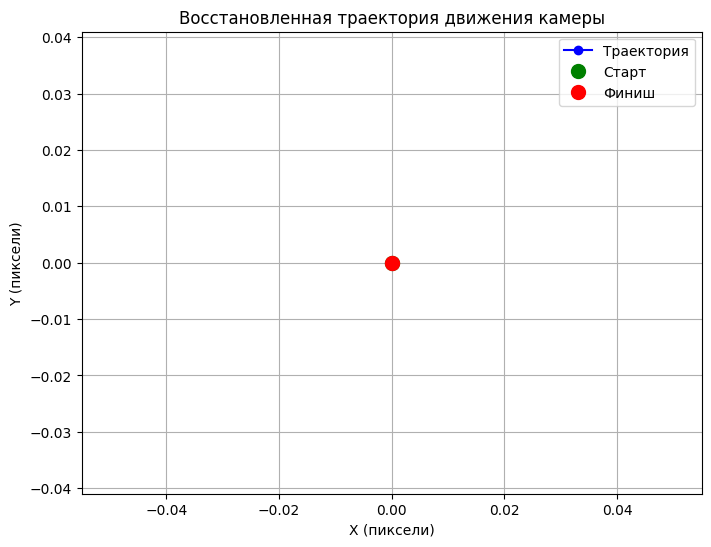

In [11]:
# Путь к папке с изображениями
image_folder = "D:\Libraries\Documents\VScode\CV_labs_Plotnikov_8E21\Lab_2\Pictures4"

trajectory, _, _, _ = visual_odometry_pipeline(image_folder, visualize=True)

# Визуализация траектории
plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], 'b-o', label='Траектория')
plt.plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=10, label='Старт')
plt.plot(trajectory[-1, 0], trajectory[-1, 1], 'ro', markersize=10, label='Финиш')
plt.xlabel('X (пиксели)')
plt.ylabel('Y (пиксели)')
plt.title('Восстановленная траектория движения камеры')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

13. Важные замечания

Адаптивный радиус и локальные максимумы реализованы через трёхмерную проверку экстремумов в масштабном пространстве (DoG пирамида).

Выравнивание яркости достигается за счёт использования разности гауссианов, что делает детектор инвариантным к изменениям освещённости.

Фильтры и перевод в градации серого написаны вручную с использованием NumPy и SciPy только для свёртки (можно было реализовать и свёртку вручную, но scipy.ndimage.convolve допускается как базовая операция).

RANSAC гарантирует устойчивость к выбросам при оценке движения.

Визуализация с помощью cv2.drawMatches разрешена условием задачи.